# Correlated Components Analysis (CorrCA) — a guided implementation

This notebook teaches you how to implement **Correlated Components Analysis** as described in
Parra, Haufe & Dmochowski, *"Correlated Components Analysis – Extracting Reliable Dimensions in
Multivariate Data"* (arXiv:1801.08881v5). Everything here is based **only** on that paper.

**Your goal:** compute the *per-subject ISC* for each subject in an EEG dataset. We build up to
that step by step, implementing every formula directly from the text, then simulating data so you
can see each piece work.

**How the notebook is organized.** For most computations you get **two functions**:

- a `*_direct` version that mirrors the paper's summation formula line-for-line (slow but
  unambiguous — you can read the equation and the code side by side), and
- a `*_fast` version that does the *exact same arithmetic* using matrix operations (what you'd
  actually run on real data).

After each pair we assert that they produce identical numbers, so you can trust the fast version.

**Assumed background:** you know what a dot product and a projection are. We explain the rest
(covariance matrices, eigenvalue problems) as we go.

## 0. Notation and data layout

The paper (Section 2.1) describes the data as a volume of size $T \times D \times N$:

| Symbol | Meaning | In EEG terms |
|--------|---------|--------------|
| $i = 1,\dots,T$ | exemplars | time samples |
| $l, k = 1,\dots,N$ | repetitions | subjects (or trials) |
| $D$ | dimensions | electrodes / channels |

A single data point is a $D$-dimensional vector $\mathbf{x}^l_i \in \mathbb{R}^D$: the activity at
all $D$ electrodes, at time $i$, for subject $l$.

We store the whole dataset in a NumPy array `X` of shape `(T, D, N)`, so that

```
X[i, :, l]  ==  x^l_i      (the D-vector for time i, subject l)
```

This ordering keeps the code readable next to the equations. We will be careful and consistent
about it everywhere.

In [1]:
import numpy as np
from scipy.linalg import eigh          # generalized eigenvalue solver
from scipy.stats import f as f_dist    # F-distribution, for significance testing later

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)

## 1. A simulator (so we have data to work with)

Section 4 / Appendix E of the paper validates CorrCA on *simulated* data with known properties:
a set of **shared signal components** that are identical across subjects, plus **subject-specific
noise**. CorrCA should then recover the shared directions.

We use a simplified version of that recipe. We create `K` shared source signals (the same time
courses for every subject), mix them into `D` channels with a shared mixing matrix, and add
independent noise per subject. The signal-to-noise ratio is controlled exactly as in Appendix E:
the observation is $\mathbf{x}^l = \xi\,\mathbf{x}^l_s + (1-\xi)\,\mathbf{x}^l_n$ with
$\xi = 10^{\mathrm{SNR}/20} / (1 + 10^{\mathrm{SNR}/20})$, after normalizing signal and noise by
their Frobenius norm.

Because the shared sources are identical across subjects, the true ISC of those dimensions is 1.

In [2]:
def simulate_eeg(T=200, D=10, N=5, K=3, snr_db=0.0, seed=0):
    '''Return X of shape (T, D, N): K shared sources + per-subject noise.

    Simplified version of the data generation in Appendix E.
    '''
    g = np.random.default_rng(seed)

    # K shared source time courses, IDENTICAL for every subject -> true ISC = 1
    S   = g.standard_normal((T, K))
    A_s = g.standard_normal((D, K))           # shared signal mixing matrix (D x K)
    Xs  = S @ A_s.T                           # (T, D) shared signal
    Xs  = Xs / np.linalg.norm(Xs)             # normalize (Frobenius)

    xi = 10**(snr_db/20) / (1 + 10**(snr_db/20))   # SNR mixing weight

    X = np.zeros((T, D, N))
    for l in range(N):
        noise = g.standard_normal((T, D))
        noise = noise / np.linalg.norm(noise)
        X[:, :, l] = xi * Xs + (1 - xi) * noise
    return X

# A small dataset for testing the direct (slow) functions, and a bigger "EEG-like" one.
X_small = simulate_eeg(T=40,  D=6,  N=4,  K=2, snr_db=0,  seed=1)
X_eeg   = simulate_eeg(T=300, D=32, N=10, K=4, snr_db=-3, seed=2)
print("X_small:", X_small.shape, "   X_eeg:", X_eeg.shape)

X_small: (40, 6, 4)    X_eeg: (300, 32, 10)


In [2]:
X_eeg = np.load("/data3/cdb/MOBI_LAB/NKI_RS2/EEG_derivatives/sub-ALL_ses-MOBI1A_task-passivepresent_run-1_eeg.npy")

## 2. What ISC actually is (paper §2.1)

CorrCA looks for a **projection vector** $\mathbf{v} \in \mathbb{R}^D$ that turns each
$D$-dimensional measurement into a single number (Eq. 1):

$$y^l_i = \mathbf{v}^\top \mathbf{x}^l_i$$

So `v` is a weighting of the electrodes, and $y^l_i$ is the value of that weighted combination at
time $i$ for subject $l$. We want to pick `v` so that this one number is **as correlated as
possible between subjects**.

The paper measures that with **inter-subject correlation (ISC)**, defined (Eq. 2) as a ratio of
*between-subject* covariance $r_B$ to *within-subject* covariance $r_W$:

$$\rho = \frac{1}{N-1}\,\frac{r_B}{r_W}$$

with (Eqs. 3–4)

$$r_B = \sum_{l=1}^{N}\sum_{\substack{k=1\\k\neq l}}^{N}\sum_{i=1}^{T}
        (y^l_i - \bar y^l)(y^k_i - \bar y^k), \qquad
  r_W = \sum_{l=1}^{N}\sum_{i=1}^{T}(y^l_i - \bar y^l)^2$$

Here $\bar y^l = \frac1T\sum_i y^l_i$ is the time-average for subject $l$.

**Reading these in words:**
- $r_W$ is how much each subject's signal varies *around its own mean* — the "within" wiggle.
- $r_B$ sums products of *different* subjects' fluctuations at the *same* time point. If two
  subjects go up and down together, those products are positive and $r_B$ is large.
- The factor $\frac{1}{N-1}$ normalizes $\rho$ so that its maximum is 1 (proved in Appendix G.2).

Note $r_B$ skips the term $k=l$ (a subject paired with itself).

### 2a. ISC on already-projected scalar signals

Let's first compute $r_B$, $r_W$, and $\rho$ directly from a projected signal $y^l_i$, exactly as
written. We store the projected data in `Y` of shape `(T, N)`, i.e. `Y[i, l] = y^l_i`.

In [3]:
def rW_scalar_direct(Y):
    '''r_W from Eq. (4), summed exactly as the formula is written.'''
    T, N = Y.shape
    ybar = Y.mean(axis=0)              # bar y^l, one per subject
    rW = 0.0
    for l in range(N):
        for i in range(T):
            rW += (Y[i, l] - ybar[l]) ** 2
    return rW

def rB_scalar_direct(Y):
    '''r_B from Eq. (3): triple sum over l, k!=l, i.'''
    T, N = Y.shape
    ybar = Y.mean(axis=0)
    rB = 0.0
    for l in range(N):
        for k in range(N):
            if k == l:
                continue
            for i in range(T):
                rB += (Y[i, l] - ybar[l]) * (Y[i, k] - ybar[k])
    return rB

def isc_scalar_direct(Y):
    '''rho from Eq. (2).'''
    N = Y.shape[1]
    return (1.0 / (N - 1)) * rB_scalar_direct(Y) / rW_scalar_direct(Y)

**The efficient version.** Center each subject's signal once, then note:
- $r_W = \sum_{l,i} (y^l_i-\bar y^l)^2$ is just the total sum of squares of the centered data.
- For $r_B$, the paper's own trick (§2.2, Eq. 12) is cleaner than the double subject-loop. Define
  the **total covariance** including the $k=l$ term:
  $$r_T = \sum_i\Big(\sum_l (y^l_i-\bar y^l)\Big)^2, \qquad r_B = r_T - r_W .$$
  This works because adding back the skipped $k=l$ terms completes the square
  $\big(\sum_l(\cdot)\big)^2$. We never loop over pairs of subjects.

In [4]:
def rW_scalar_fast(Y):
    Yc = Y - Y.mean(axis=0, keepdims=True)    # center each subject (column)
    return np.sum(Yc**2)

def rB_scalar_fast(Y):
    Yc = Y - Y.mean(axis=0, keepdims=True)
    rT = np.sum(Yc.sum(axis=1)**2)            # sum_i ( sum_l centered )^2  = r_T
    rW = np.sum(Yc**2)
    return rT - rW                            # r_B = r_T - r_W   (Eq. 12)

def isc_scalar_fast(Y):
    N = Y.shape[1]
    return (1.0 / (N - 1)) * rB_scalar_fast(Y) / rW_scalar_fast(Y)

# --- verify direct == fast on a random projection of the small dataset ---
v_test = rng.standard_normal(X_small.shape[1])
Y_test = np.einsum('idl,d->il', X_small, v_test)   # project: Y[i,l] = v . x^l_i

assert np.isclose(rW_scalar_direct(Y_test), rW_scalar_fast(Y_test))
assert np.isclose(rB_scalar_direct(Y_test), rB_scalar_fast(Y_test))
assert np.isclose(isc_scalar_direct(Y_test), isc_scalar_fast(Y_test))
print("scalar ISC (direct):", isc_scalar_direct(Y_test))
print("scalar ISC (fast)  :", isc_scalar_fast(Y_test))
print("match:", np.isclose(isc_scalar_direct(Y_test), isc_scalar_fast(Y_test)))

scalar ISC (direct): 0.3909666912092777
scalar ISC (fast)  : 0.390966691209278
match: True


## 3. From scalars to covariance matrices (paper §2.1, Eqs. 5–7)

Computing $\rho$ for one fixed `v` is easy, but we want the *best* `v`. The trick is that $\rho$
can be written entirely with **matrices that don't depend on `v`** (Eq. 5):

$$\rho = \frac{1}{N-1}\,\frac{\mathbf{v}^\top \mathbf{R}_B \mathbf{v}}
                                {\mathbf{v}^\top \mathbf{R}_W \mathbf{v}}$$

where $\mathbf{R}_B$ and $\mathbf{R}_W$ are $D\times D$ matrices defined just like $r_B, r_W$ but
with **outer products** of the $D$-vectors instead of products of scalars (Eqs. 6–7):

$$\mathbf{R}_B = \sum_{i=1}^{T}\sum_{l=1}^{N}\sum_{\substack{k=1\\k\neq l}}^{N}
   (\mathbf{x}^l_i-\bar{\mathbf{x}}^l)(\mathbf{x}^k_i-\bar{\mathbf{x}}^k)^\top, \qquad
  \mathbf{R}_W = \sum_{i=1}^{T}\sum_{l=1}^{N}
   (\mathbf{x}^l_i-\bar{\mathbf{x}}^l)(\mathbf{x}^l_i-\bar{\mathbf{x}}^l)^\top$$

An **outer product** $\mathbf{d}\,\mathbf{d}^\top$ of a $D$-vector is a $D\times D$ matrix; summing
these gives a covariance matrix. The scalar versions from Section 2 are exactly
$\mathbf{v}^\top \mathbf{R}_W \mathbf{v} = r_W$ and $\mathbf{v}^\top \mathbf{R}_B \mathbf{v} = r_B$.

In [5]:
def RW_direct(X):
    '''Within-subject covariance, Eq. (7), summed exactly as written.'''
    T, D, N = X.shape
    RW = np.zeros((D, D))
    for l in range(N):
        xbar_l = X[:, :, l].mean(axis=0)            # bar x^l  (D-vector), mean over time
        for i in range(T):
            d = X[i, :, l] - xbar_l
            RW += np.outer(d, d)                    # d d^T
    return RW

def RB_direct(X):
    '''Between-subject covariance, Eq. (6): triple sum i, l, k!=l.'''
    T, D, N = X.shape
    xbar = X.mean(axis=0)                           # (D, N): bar x^l for every subject
    RB = np.zeros((D, D))
    for i in range(T):
        for l in range(N):
            dl = X[i, :, l] - xbar[:, l]
            for k in range(N):
                if k == l:
                    continue
                dk = X[i, :, k] - xbar[:, k]
                RB += np.outer(dl, dk)
    return RB

**The efficient version uses the §2.2 "fast computation" idea.** The paper points out (Eqs.
12–14) that the *total* covariance $\mathbf{R}_T = \mathbf{R}_B + \mathbf{R}_W$ (the version that
keeps the $k=l$ term) collapses to a sum over the **subject-average** signal:

$$\mathbf{R}_T = N^2 \sum_{i=1}^{T}(\bar{\mathbf{x}}^*_i - \bar{\mathbf{x}}^{**})
                                   (\bar{\mathbf{x}}^*_i - \bar{\mathbf{x}}^{**})^\top$$

where $\bar{\mathbf{x}}^*_i = \frac1N\sum_l \mathbf{x}^l_i$ is the mean across subjects at time
$i$, and $\bar{\mathbf{x}}^{**}$ is the grand mean. Then $\mathbf{R}_B = \mathbf{R}_T - \mathbf{R}_W$.

This is the paper's key efficiency result: **you never correlate pairs of subjects** (which would
cost $O(N^2)$); both $\mathbf{R}_W$ and $\mathbf{R}_T$ cost only $O(N)$.

In [6]:
def RW_fast(X):
    '''Eq. (7) via one matrix multiply.'''
    T, D, N = X.shape
    Xc = X - X.mean(axis=0, keepdims=True)          # center each subject over time
    M  = Xc.transpose(1, 0, 2).reshape(D, T * N)    # stack all (i,l) columns -> (D, T*N)
    return M @ M.T                                  # sum of outer products

def RT_fast(X):
    '''Total covariance via Eq. (14): sum over subject-averaged signal.'''
    T, D, N = X.shape
    xbar_star_i = X.mean(axis=2)                    # bar x^*_i  (T, D): mean across subjects
    grand       = xbar_star_i.mean(axis=0)          # bar x^**   (D,)
    M = xbar_star_i - grand
    return N**2 * (M.T @ M)

def RB_fast(X):
    '''Eq. (6) without any pairwise loop:  R_B = R_T - R_W   (Eq. 12).'''
    return RT_fast(X) - RW_fast(X)

# --- verify on the small dataset (direct functions are too slow for big data) ---
assert np.allclose(RW_direct(X_small), RW_fast(X_small))
assert np.allclose(RB_direct(X_small), RB_fast(X_small))
print("R_W and R_B: direct == fast  ->", 
      np.allclose(RW_direct(X_small), RW_fast(X_small)) and
      np.allclose(RB_direct(X_small), RB_fast(X_small)))

# sanity: v^T R v should reproduce the scalar r_W, r_B from Section 2
RW_s, RB_s = RW_fast(X_small), RB_fast(X_small)
print("v^T R_W v vs r_W :", v_test @ RW_s @ v_test, rW_scalar_fast(Y_test))
print("v^T R_B v vs r_B :", v_test @ RB_s @ v_test, rB_scalar_fast(Y_test))

R_W and R_B: direct == fast  -> True
v^T R_W v vs r_W : 0.21387513036170872 0.21387513036170874
v^T R_B v vs r_B : 0.2508541561484106 0.2508541561484108


## 4. Finding the best projections: the eigenvalue problem (paper §2.1, Eqs. 8–11)

We want the `v` that maximizes $\rho = \frac{1}{N-1}\frac{\mathbf{v}^\top\mathbf{R}_B\mathbf{v}}
{\mathbf{v}^\top\mathbf{R}_W\mathbf{v}}$. Setting the derivative to zero (Eq. 8) gives a
**generalized eigenvalue problem**:

$$\mathbf{R}_B\,\mathbf{v} = \lambda\,\mathbf{R}_W\,\mathbf{v}$$

You don't need to know the proof; what matters:

- The solutions $\mathbf{v}_d$ are the **generalized eigenvectors** of the matrix pair
  $(\mathbf{R}_B, \mathbf{R}_W)$. Each one is a candidate projection (a set of electrode weights).
- The eigenvector with the **largest** eigenvalue gives the projection with **maximum ISC**.
- Smaller eigenvectors give further projections that are *uncorrelated* with the earlier ones
  (Eq. 11, $\mathbf{V}^\top\mathbf{R}_W\mathbf{V}$ is diagonal), so each captures something new.

We stack all eigenvectors as columns of a matrix $\mathbf{V} = [\mathbf{v}_1,\dots,\mathbf{v}_D]$
(Eq. 10: $\mathbf{R}_B\mathbf{V} = \mathbf{R}_W\mathbf{V}\Lambda$).

The eigenvalue $\lambda$ returned by the solver is the Rayleigh quotient
$\mathbf{v}^\top\mathbf{R}_B\mathbf{v}/\mathbf{v}^\top\mathbf{R}_W\mathbf{v}$; the ISC itself is
$\rho = \lambda/(N-1)$ (Eq. 2/5). To avoid any ambiguity we always compute $\rho$ straight from its
definition (Eq. 5) rather than reading it off the solver.

In [7]:
def corrca(X, RW=None, RB=None):
    '''Solve CorrCA. Returns V (D x D, columns = components, sorted by ISC),
    and the ISC value rho_d of each component computed from Eq. (5).'''
    T, D, N = X.shape
    if RW is None: RW = RW_fast(X)
    if RB is None: RB = RB_fast(X)

    # generalized eigenproblem  R_B v = lambda R_W v   (Eq. 8)
    eigvals, V = eigh(RB, RW)                  # ascending order
    order = np.argsort(eigvals)[::-1]          # sort descending (largest ISC first)
    V = V[:, order]

    # ISC of each component, directly from Eq. (5):  rho = (1/(N-1)) v^T R_B v / v^T R_W v
    rho = np.array([(1.0/(N-1)) * (V[:, d] @ RB @ V[:, d]) / (V[:, d] @ RW @ V[:, d])
                    for d in range(D)])
    return V, rho

V, rho = corrca(X_small)
print("ISC per component (small dataset):", rho)
# The first components should have the highest ISC and be near the simulated true value.

ISC per component (small dataset): [ 0.8306  0.2571 -0.0108 -0.0313 -0.063  -0.1128]


**Projecting the data onto the components.** Once we have `V`, component $d$ of every
subject is $y^l_i = \mathbf{v}_d^\top \mathbf{x}^l_i$. We compute all of them at once.

In [8]:
def project_component(X, v):
    '''Return Y of shape (T, N) with Y[i, l] = v . x^l_i  (Eq. 1).'''
    return np.einsum('idl,d->il', X, v)

def project_all(X, V):
    '''Return Y of shape (T, N, D): Y[i, l, d] = v_d . x^l_i for every component d.'''
    return np.einsum('idl,dc->ilc', X, V)

# Check: the ISC of the projected first component matches rho[0] from corrca
Y1 = project_component(X_small, V[:, 0])
print("ISC of projected comp 1 :", isc_scalar_fast(Y1))
print("rho[0] from corrca      :", rho[0])

ISC of projected comp 1 : 0.83060251186852
rho[0] from corrca      : 0.83060251186852


## 5. The forward model (paper §2.5, Eqs. 27–28)

CorrCA is a *backward model*: it maps measurements to components ($\mathbf{y}=\mathbf{V}^\top
\mathbf{x}$). The weights in `V` are **not** directly interpretable as "where on the scalp this
component lives" — for that you need the **forward model** $\mathbf{A}$, the pattern that best
reconstructs the data from the components (Eq. 27, $\hat{\mathbf{x}} = \mathbf{A}\mathbf{y}$).

The paper gives its least-squares solution (Eq. 28):

$$\hat{\mathbf{A}} = \mathbf{R}_W \mathbf{V}\,(\mathbf{V}^\top \mathbf{R}_W \mathbf{V})^{-1}$$

Each column $\mathbf{a}_d$ is the scalp topography of component $d$ — that's what you plot as a
head map to interpret a component.

In [9]:
def forward_model(X, V, RW=None):
    '''Forward model A from Eq. (28): A = R_W V (V^T R_W V)^{-1}.'''
    if RW is None: RW = RW_fast(X)
    return RW @ V @ np.linalg.inv(V.T @ RW @ V)

A = forward_model(X_small, V)
print("Forward model shape (D x D):", A.shape)
print("Column a_1 (topography of component 1):", A[:, 0])

Forward model shape (D x D): (6, 6)
Column a_1 (topography of component 1): [-0.2945  0.7738 -0.3874  0.2445 -0.2511 -0.2756]


## 6. Regularization — important for real EEG (paper Appendix C, §3.5)

Solving $\mathbf{R}_B\mathbf{v}=\lambda\mathbf{R}_W\mathbf{v}$ requires inverting $\mathbf{R}_W$.
With real EEG, $\mathbf{R}_W$ often has tiny eigenvalues (near-collinear channels). Dividing by
them blows up noise and produces **spuriously high ISC** (Appendix C).

The paper uses two fixes. The simpler one is **shrinkage** (Eq. 63):

$$\tilde{\mathbf{R}}_W = (1-\gamma)\,\mathbf{R}_W + \gamma\,\bar\lambda\,\mathbf{I},
  \qquad \bar\lambda = \mathrm{Tr}(\mathbf{R}_W)/D,\quad 0\le\gamma\le 1$$

This pulls small eigenvalues up and large ones down. $\gamma=0$ is no regularization; larger
$\gamma$ is stronger. The other fix, **TSVD** (Eqs. 59–61), keeps only the top $K$ eigenvectors of
$\mathbf{R}_W$. We implement both.

In [10]:
def shrinkage(RW, gamma):
    '''Shrinkage-regularized within-subject covariance, Eq. (63).'''
    D = RW.shape[0]
    lam_bar = np.trace(RW) / D                       # mean eigenvalue
    return (1 - gamma) * RW + gamma * lam_bar * np.eye(D)

def tsvd_inverse(RW, K):
    '''Regularized inverse of R_W keeping K principal eigenvectors, Eqs. (60)-(61).'''
    vals, vecs = np.linalg.eigh(RW)                  # ascending
    idx = np.argsort(vals)[::-1][:K]                 # K largest
    U, L = vecs[:, idx], vals[idx]
    return U @ np.diag(1.0 / L) @ U.T                # tilde R_W^{-1}

def corrca_regularized(X, gamma=0.0, K=None):
    '''CorrCA with optional shrinkage (gamma) or TSVD (K). Returns V, rho.'''
    T, D, N = X.shape
    RW, RB = RW_fast(X), RB_fast(X)

    if K is not None:                                # TSVD path
        RW_inv = tsvd_inverse(RW, K)
        eigvals, V = np.linalg.eig(RW_inv @ RB)      # solve (R_W^{-1} R_B) v = lambda v
        V = np.real(V); eigvals = np.real(eigvals)
    else:                                            # shrinkage path
        RW_reg = shrinkage(RW, gamma)
        eigvals, V = eigh(RB, RW_reg)                # regularized R_W only to FIND directions

    order = np.argsort(eigvals)[::-1]
    V = V[:, order]
    # ISC is always measured against the TRUE (unregularized) R_W, Eq. (5),
    # so it respects the bound rho <= 1 (Appendix G.2). Regularization only
    # affects which directions V we find, not how we score them.
    rho = np.array([(1.0/(N-1)) * (V[:, d] @ RB @ V[:, d]) / (V[:, d] @ RW @ V[:, d])
                    for d in range(V.shape[1])])
    return V, rho

V_reg, rho_reg = corrca_regularized(X_eeg, gamma=0.4)
print("ISC, first 6 components (shrinkage gamma=0.4):", rho_reg[:6])

ISC, first 6 components (shrinkage gamma=0.4): [0.8512 0.8038 0.7661 0.7458 0.0731 0.0616]


## 7. Is a component significant? The F-statistic (paper §2.4, Appendix D)

The paper shows (Eq. 26) that for **independent** samples the ISC maps to an F-statistic:

$$F = \frac{T(N-1)\,\rho + T}{(T-1)(1-\rho)}$$

which follows an F-distribution with degrees of freedom $d_1 = T(N-1)$ and $d_2 = T-1$. So you can
get a p-value for each component.

**Two cautions straight from the paper:**
1. This test is only valid on **held-out test data** and when the means are equalized — you can't
   use it on the same data you optimized `v` on (Appendix D, §2.4).
2. It assumes **IID** samples. EEG time samples are autocorrelated, so the paper recommends
   *circular-shift shuffle statistics* instead for time series (Appendix D). We implement the
   parametric test below because it's a closed form; treat it as illustrative for time series.

Because there are $D$ components tested, the paper applies a **Bonferroni** correction: keep
components with $p < \alpha/D$.

In [11]:
def f_statistic(rho, T, N):
    '''F-statistic from Eq. (26).'''
    return (T * (N - 1) * rho + T) / ((T - 1) * (1 - rho))

def isc_pvalues(rho, T, N):
    '''Parametric p-values for each component's ISC (Eq. 26 + F-distribution).'''
    F = f_statistic(rho, T, N)
    d1, d2 = T * (N - 1), T - 1
    return f_dist.sf(F, d1, d2)        # upper-tail probability

# Illustrative: split into train/test, fit on train, test ISC + p-value on test (per Appendix D)
T, D, N = X_eeg.shape
half = T // 2
X_tr, X_te = X_eeg[:half], X_eeg[half:]

V_tr, _ = corrca_regularized(X_tr, gamma=0.4)         # learn projections on training half
Y_te = project_all(X_te, V_tr)                         # apply to test half
rho_te = np.array([isc_scalar_fast(Y_te[:, :, d]) for d in range(D)])   # test ISC per component

p = isc_pvalues(rho_te, T=half, N=N)
alpha = 0.05
sig = p < (alpha / D)                                  # Bonferroni
print("test ISC (first 6):", rho_te[:6])
print("p-values  (first 6):", p[:6])
print("number of significant components:", sig.sum())

test ISC (first 6): [ 0.8503  0.7964  0.7651  0.7485 -0.0165 -0.0105]
p-values  (first 6): [0.     0.     0.     0.     0.9283 0.8129]
number of significant components: 4


## 8. Per-subject ISC — your goal (paper Appendix G.3, Eqs. 84–85)

The overall ISC is one number for the whole group. Often you want to know **how strongly each
individual subject correlates with the rest of the group** — e.g. as an engagement / attention
measure. The paper defines this single-subject ISC (Appendix G.3, Eqs. 84–85):

$$\rho_k = \frac{\sum_{l\neq k}\,(r_{kl} + r_{lk})}{\sum_{l\neq k}\,(r_{ll} + r_{kk})},
  \qquad
  r_{kl} = \sum_{i=1}^{T}(y^k_i - \bar y^k)(y^l_i - \bar y^l)$$

In words: $r_{kl}$ is the (unnormalized) covariance between subject $k$'s and subject $l$'s
projected time courses. The numerator sums subject $k$'s covariance with **every other** subject;
the denominator sums the corresponding self-covariances (variances). It's "subject $k$ vs the
group", computed per component, on the projected signal $y^l_i = \mathbf{v}_d^\top\mathbf{x}^l_i$.

In [12]:
def per_subject_isc_direct(Y):
    '''Per-subject ISC for one component, Eqs. (84)-(85), summed exactly as written.
    Y has shape (T, N): the projected component, Y[i, l] = y^l_i.
    Returns rho of shape (N,).'''
    T, N = Y.shape
    ybar = Y.mean(axis=0)                       # bar y^l for each subject

    def r(k, l):                                # r_{kl}, Eq. (85)
        s = 0.0
        for i in range(T):
            s += (Y[i, k] - ybar[k]) * (Y[i, l] - ybar[l])
        return s

    rho = np.zeros(N)
    for k in range(N):
        num = 0.0
        den = 0.0
        for l in range(N):
            if l == k:
                continue
            num += r(k, l) + r(l, k)            # numerator of Eq. (84)
            den += r(l, l) + r(k, k)            # denominator of Eq. (84)
        rho[k] = num / den
    return rho

**Efficient version.** Every $r_{kl}$ is an entry of the $N\times N$ matrix
$\mathbf{R} = \mathbf{Y}_c^\top \mathbf{Y}_c$ where $\mathbf{Y}_c$ is the time-centered component
(one matrix multiply gives all pairs at once). Then Eq. (84) is just row/column sums of
$\mathbf{R}$.

In [13]:
def per_subject_isc_fast(Y):
    '''Same as per_subject_isc_direct, vectorized. Y shape (T, N) -> rho shape (N,).'''
    T, N = Y.shape
    Yc = Y - Y.mean(axis=0, keepdims=True)      # center each subject over time
    R  = Yc.T @ Yc                              # R[k, l] = r_{kl}  (all pairs at once)
    diag = np.diag(R)                           # r_{kk}
    rho = np.zeros(N)
    for k in range(N):
        off = np.arange(N) != k                 # the l != k entries
        num = (R[k, off] + R[off, k]).sum()     # sum_{l!=k} (r_kl + r_lk)
        den = (diag[off] + diag[k]).sum()       # sum_{l!=k} (r_ll + r_kk)
        rho[k] = num / den
    return rho

# --- verify direct == fast ---
Y1 = project_component(X_small, V[:, 0])
assert np.allclose(per_subject_isc_direct(Y1), per_subject_isc_fast(Y1))
print("per-subject ISC, component 1 (direct):", per_subject_isc_direct(Y1))
print("per-subject ISC, component 1 (fast)  :", per_subject_isc_fast(Y1))
print("match:", np.allclose(per_subject_isc_direct(Y1), per_subject_isc_fast(Y1)))

per-subject ISC, component 1 (direct): [0.8354 0.8275 0.8416 0.8173]
per-subject ISC, component 1 (fast)  : [0.8354 0.8275 0.8416 0.8173]
match: True


## 9. Full pipeline: per-subject ISC for every subject and component

Putting it all together, the recipe for your EEG data is:

1. Arrange your data as `X` with shape `(T, D, N)` = (time, channels, subjects).
2. Compute $\mathbf{R}_W$ and $\mathbf{R}_B$ (use the fast functions).
3. Solve the eigenvalue problem with regularization (shrinkage `gamma`, or `K` for TSVD) to get
   the projection matrix `V` and the group ISC of each component.
4. Project the data onto each component.
5. For each component, compute the per-subject ISC (Eqs. 84–85).

The result is an `N x D` table: row = subject, column = component.

In [14]:
def corrca_per_subject_isc(X, gamma=0.0, K=None):
    '''End-to-end. Returns:
        V        : (D, D) projection matrix (columns = components, sorted by group ISC)
        rho_grp  : (D,)   group ISC of each component
        rho_subj : (N, D) per-subject ISC, rho_subj[l, d] = subject l on component d
        A        : (D, D) forward models (columns = component topographies)
    '''
    T, D, N = X.shape
    V, rho_grp = corrca_regularized(X, gamma=gamma, K=K)
    RW = shrinkage(RW_fast(X), gamma) if K is None else RW_fast(X)
    A  = forward_model(X, V, RW)

    Y = project_all(X, V)                                  # (T, N, D)
    rho_subj = np.zeros((N, D))
    for d in range(D):
        rho_subj[:, d] = per_subject_isc_fast(Y[:, :, d])  # (N,) for this component
    return V, rho_grp, rho_subj, A

V, rho_grp, rho_subj, A = corrca_per_subject_isc(X_eeg, gamma=0.4)

print("Group ISC, first 5 components:", rho_grp[:5])
print()
print("Per-subject ISC table (rows = subjects, cols = first 5 components):")
print(rho_subj[:, :5])

Group ISC, first 5 components: [0.8512 0.8038 0.7661 0.7458 0.0731]

Per-subject ISC table (rows = subjects, cols = first 5 components):
[[0.8514 0.8111 0.7684 0.7368 0.0744]
 [0.8412 0.8084 0.761  0.7536 0.0705]
 [0.8558 0.7996 0.7772 0.7418 0.0192]
 [0.8541 0.8025 0.7685 0.7363 0.0947]
 [0.8614 0.8118 0.7645 0.7434 0.0721]
 [0.8536 0.8026 0.7633 0.7674 0.1059]
 [0.844  0.7987 0.7677 0.7422 0.0919]
 [0.8582 0.8093 0.7549 0.7663 0.0693]
 [0.8393 0.7955 0.7626 0.7264 0.0466]
 [0.8527 0.7983 0.7717 0.7421 0.0818]]


### A quick look at the result

Component 1 has the highest group ISC by construction. The per-subject ISC for component 1 tells
you how much each subject's brain response aligns with the group on that most-reliable dimension.
Let's visualize the first few components.

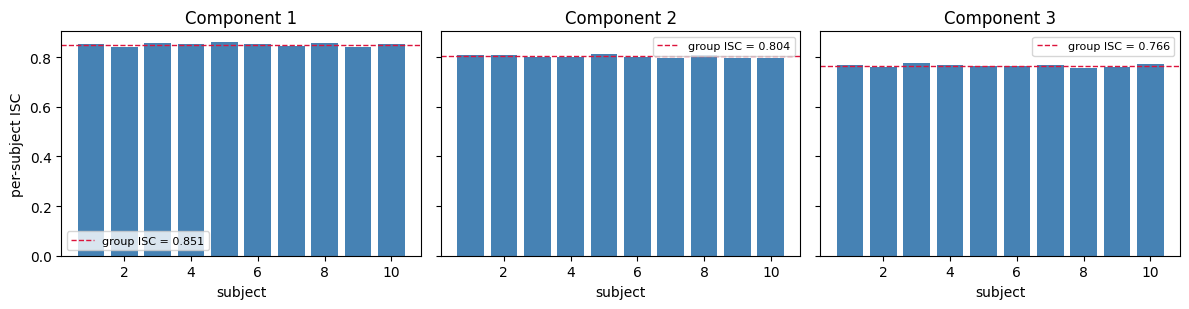

In [15]:
import matplotlib.pyplot as plt

n_show = 3
fig, axes = plt.subplots(1, n_show, figsize=(4*n_show, 3.2), sharey=True)
N = X_eeg.shape[2]
for d in range(n_show):
    axes[d].bar(np.arange(1, N+1), rho_subj[:, d], color="steelblue")
    axes[d].axhline(rho_grp[d], color="crimson", ls="--", lw=1,
                    label=f"group ISC = {rho_grp[d]:.3f}")
    axes[d].set_title(f"Component {d+1}")
    axes[d].set_xlabel("subject")
    axes[d].legend(fontsize=8)
axes[0].set_ylabel("per-subject ISC")
plt.tight_layout()
plt.show()

## 10. Summary & checklist for your own data

**What each piece does:**

- **§2–3** $\mathbf{R}_W$, $\mathbf{R}_B$ — the within- and between-subject covariance matrices.
  These contain everything CorrCA needs; computed in $O(N)$ via the $\mathbf{R}_T = \mathbf{R}_B +
  \mathbf{R}_W$ trick (Eq. 12–14).
- **§4** `corrca` — solves $\mathbf{R}_B\mathbf{v}=\lambda\mathbf{R}_W\mathbf{v}$ for the
  projections `V`, sorted by ISC.
- **§5** `forward_model` — the topographies you plot/interpret (Eq. 28).
- **§6** `shrinkage` / `tsvd_inverse` — regularize $\mathbf{R}_W$ so you don't get fake ISC. **Use
  this on real EEG.** Pick `gamma` (or `K`) by maximizing *test-set* ISC (paper §3.5).
- **§7** `isc_pvalues` — parametric significance, valid on held-out IID data. For EEG time series
  the paper prefers circular-shift shuffle statistics (Appendix D).
- **§8** `per_subject_isc_fast` — your target: Eqs. 84–85, subject-vs-group ISC per component.

**Practical reminders from the paper:**

- The fundamental assumption of CorrCA is that the shared signal projects in the **same direction
  across subjects** (§4.3). If subjects differ a lot, consider MCCA (§2.6).
- The sign of each $\mathbf{v}_d$ / component is arbitrary (Appendix A.3) — don't over-interpret it.
- Components with very close ISC values are not individually identifiable, only as a subspace
  (Appendix A.3).
- Equalize subject means (zero-mean signals) so the equivalences and the F-test hold (§2.3, §2.4).

**To run on your real data:** replace `X_eeg` with your array shaped `(T, D, N)`, choose `gamma`
by cross-validating test ISC, then call `corrca_per_subject_isc(X, gamma=...)`.

In [17]:
def select_gamma(X, gammas=None, n_components=3, n_folds=5):
    """Choose shrinkage gamma by maximizing held-out test ISC (paper §3.5).
    Time is split into n_folds CONTIGUOUS blocks; all subjects kept in every fold.
    Score = summed test ISC over the first n_components. gamma values where R_W is
    not invertible (rank-deficient data) are skipped.
    Returns: best_gamma, gammas, mean_test_score (per gamma)."""
    T, D, N = X.shape
    if gammas is None:
        gammas = np.round(np.linspace(0.0, 0.9, 15), 3)
    bounds = np.linspace(0, T, n_folds + 1).astype(int)
    scores = np.full((len(gammas), n_folds), np.nan)
    for fi in range(n_folds):
        is_test = np.zeros(T, bool); is_test[bounds[fi]:bounds[fi+1]] = True
        X_tr, X_te = X[~is_test], X[is_test]
        for gi, g in enumerate(gammas):
            try:
                V, _ = corrca_regularized(X_tr, gamma=g)        # fit on train samples
                Y_te = project_all(X_te, V)                     # apply to test samples
                isc_te = [isc_scalar_fast(Y_te[:, :, d]) for d in range(n_components)]
                scores[gi, fi] = np.sum(isc_te)
            except np.linalg.LinAlgError:
                scores[gi, fi] = np.nan                         # R_W singular at this gamma
    mean_score = np.nanmean(scores, axis=1)
    valid = ~np.isnan(mean_score)
    best_gamma = gammas[valid][int(np.argmax(mean_score[valid]))]
    return best_gamma, gammas, mean_score

# usage:
best_gamma, gammas, scores = select_gamma(X_eeg, n_components=3, n_folds=5)
print("best gamma:", best_gamma)

: 

## 11. New stuff

In [1]:
import pandas as pd
from nki_rs2_eeg.config import TASK_ID, RUN_ID, SESSION_ID, DERIVATIVES_DIR


processed_files = list(
        DERIVATIVES_DIR.rglob(f'sub-*{SESSION_ID}*{TASK_ID}*run-{RUN_ID}_eeg.edf')
    )
processed_files
# Separate the Saline and Gel Caps
caps = pd.read_csv('/home/bgonzalez/NKI_RS2_EEG/data/caps/captypes_clean.csv')
caps['a_number'] = 'sub-'+ caps['a_number']
saline_subjects = caps.loc[caps.cap_type == 'RNP-BA-64.bvef'].a_number.tolist()
gel_subjects = caps.loc[caps.cap_type != 'RNP-BA-64.bvef'].a_number.tolist()

processed_files

[PosixPath('/data3/cdb/MOBI_LAB/NKI_RS2/EEG_derivatives/sub-A00017133/ses-MOBI1A/eeg/sub-A00017133_ses-MOBI1A_task-passivepresent_run-1_eeg.edf'),
 PosixPath('/data3/cdb/MOBI_LAB/NKI_RS2/EEG_derivatives/sub-A00077134/ses-MOBI1A/eeg/sub-A00077134_ses-MOBI1A_task-passivepresent_run-1_eeg.edf'),
 PosixPath('/data3/cdb/MOBI_LAB/NKI_RS2/EEG_derivatives/sub-A00077622/ses-MOBI1A/eeg/sub-A00077622_ses-MOBI1A_task-passivepresent_run-1_eeg.edf'),
 PosixPath('/data3/cdb/MOBI_LAB/NKI_RS2/EEG_derivatives/sub-A00079353/ses-MOBI1A/eeg/sub-A00079353_ses-MOBI1A_task-passivepresent_run-1_eeg.edf'),
 PosixPath('/data3/cdb/MOBI_LAB/NKI_RS2/EEG_derivatives/sub-A00075407/ses-MOBI1A/eeg/sub-A00075407_ses-MOBI1A_task-passivepresent_run-1_eeg.edf'),
 PosixPath('/data3/cdb/MOBI_LAB/NKI_RS2/EEG_derivatives/sub-A00075895/ses-MOBI1A/eeg/sub-A00075895_ses-MOBI1A_task-passivepresent_run-1_eeg.edf'),
 PosixPath('/data3/cdb/MOBI_LAB/NKI_RS2/EEG_derivatives/sub-A00077304/ses-MOBI1A/eeg/sub-A00077304_ses-MOBI1A_task-pas

In [16]:
#f = processed_files[150]
#f.parts[6]
gel_files = [f for f in processed_files if f.parts[6] in gel_subjects]
print(len(gel_subjects))
print(len(gel_files))
saline_files = [f for f in processed_files if f.parts[6] in saline_subjects]
print(len(saline_subjects))
print(len(saline_files))

42
1
1399
304


In [15]:
gel_subjects

['sub-A00052319',
 'sub-A00052319',
 'sub-A00052319',
 'sub-A00060005',
 'sub-A00060005',
 'sub-A00058503',
 'sub-A00040640',
 'sub-A00083138',
 'sub-A00083138',
 'sub-A00083138',
 'sub-A00083138',
 'sub-A00083138',
 'sub-A00054919',
 'sub-A00054919',
 'sub-A00054919',
 'sub-A00076381',
 'sub-A00076381',
 'sub-A00076381',
 'sub-A00074808',
 'sub-A00074808',
 'sub-A00074641',
 'sub-A00074641',
 'sub-A00074641',
 'sub-A00086169',
 'sub-A00086169',
 'sub-A00086169',
 'sub-A00086169',
 'sub-A00048030',
 'sub-A00048030',
 'sub-A00048030',
 'sub-A00055542',
 'sub-A00055542',
 'sub-A00055751',
 'sub-A00054915',
 'sub-A00054915',
 'sub-A00054915',
 'sub-A00082513',
 'sub-A00082513',
 'sub-A00077099',
 'sub-A00077099',
 'sub-A00077099',
 'sub-A00077099']

In [2]:
# %%
import numpy as np
import mne

def load_edf_to_corrca(paths, picks="eeg", common_channels=None, sfreq=None,
                       onset_annotation=None, tmin=0.0, tmax=None,
                       dtype=np.float32, verbose=True):
    """Load per-subject .edf files into a (T, D, N) array for CorrCA.

    paths            : list of .edf paths, one per subject.
    picks            : channel selection for raw.pick (default "eeg").
    common_channels  : channels to keep IN THIS ORDER for every subject;
                       None = use the intersection across all files (order from first file).
    sfreq            : None requires all files to share a rate; a number resamples everyone to it.
    onset_annotation : description of the stimulus-onset marker; if given, each subject is
                       aligned so t=0 is that marker's onset. THIS is what makes ISC meaningful.
    tmin, tmax       : crop window in seconds, relative to the onset (or file start if none).
    dtype            : float32 halves memory; covariances are computed in float64 downstream.

    Returns X (T, D, N, zero-meaned per subject), ch_names (axis-D order), sfreq_out.
    """
    N = len(paths)
    if N == 0:
        raise ValueError("paths is empty")

    # ---- Pass 1: headers only (cheap) — fix channel set/order and sampling rate ----
    headers = []
    for f in paths:
        raw = mne.io.read_raw_edf(f, preload=False, verbose="ERROR"); raw.pick(picks)
        headers.append((set(raw.ch_names), raw.ch_names, raw.info["sfreq"]))

    rates = {h[2] for h in headers}
    if sfreq is None:
        if len(rates) > 1:
            raise ValueError(f"Files have different sampling rates {sorted(rates)}; "
                             f"pass sfreq=<target> to resample to a common rate.")
        sfreq_out = rates.pop()
    else:
        sfreq_out = float(sfreq)

    if common_channels is None:
        inter = set.intersection(*[h[0] for h in headers])
        common_channels = [c for c in headers[0][1] if c in inter]
        dropped = [c for c in headers[0][1] if c not in inter]
        if verbose and dropped:
            print(f"[warn] dropped {len(dropped)} channel(s) absent in some files: {dropped}")
    else:
        for s, names, _ in headers:
            missing = [c for c in common_channels if c not in s]
            if missing:
                raise ValueError(f"A file is missing required channels: {missing}")
    D = len(common_channels)
    if verbose:
        print(f"Using {D} channels, sfreq={sfreq_out} Hz, {N} subjects")

    # ---- Pass 2: load, resample, align, crop, collect (float32) ----
    per_subject, lengths = [], []
    for i, f in enumerate(paths):
        raw = mne.io.read_raw_edf(f, preload=True, verbose="ERROR"); raw.pick(picks)
        if sfreq is not None and raw.info["sfreq"] != sfreq_out:
            raw.resample(sfreq_out, verbose="ERROR")
        raw.reorder_channels(common_channels)                # identical channel order

        onset = 0.0
        if onset_annotation is not None:
            descs = list(raw.annotations.description)
            matches = [j for j, d in enumerate(descs) if d == onset_annotation]
            if not matches:
                raise ValueError(f"'{onset_annotation}' annotation not found in {f}")
            onset = float(raw.annotations.onset[matches[0]])
        raw.crop(tmin=onset + tmin,
                 tmax=None if tmax is None else onset + tmax, verbose="ERROR")

        data = raw.get_data().T.astype(dtype)                # (T_i, D)
        per_subject.append(data); lengths.append(data.shape[0])

    # ---- common length, assemble (T, D, N), zero-mean per subject ----
    T = min(lengths)
    if verbose and len(set(lengths)) > 1:
        print(f"[warn] lengths differ ({min(lengths)}..{max(lengths)}); truncating to {T}")
    X = np.empty((T, D, N), dtype=dtype)
    for i in range(N):
        X[:, :, i] = per_subject[i][:T]
        per_subject[i] = None                                # free as we go
    X -= X.mean(axis=0, keepdims=True)                       # required by the ISC definition
    if verbose:
        print(f"X shape: {X.shape}  (T={T}, D={D}, N={N}), dtype={X.dtype}")
    return X, common_channels, sfreq_out

In [3]:
# %%
X, common_channels, sfreq_out = load_edf_to_corrca(paths=processed_files, onset_annotation="Onset Movie",tmax=207)

Using 64 channels, sfreq=250.0 Hz, 304 subjects
X shape: (51751, 64, 304)  (T=51751, D=64, N=304), dtype=float32


In [4]:
# %%
def RW_fast(X):
    """Within-subject covariance, Eq. (7). Memory-safe: loops over subjects."""
    T, D, N = X.shape
    RW = np.zeros((D, D))                                  # float64 accumulator
    for l in range(N):
        Xl = np.asarray(X[:, :, l], dtype=np.float64)      # one subject, (T, D)
        Xl -= Xl.mean(axis=0)                              # center over time
        RW += Xl.T @ Xl
    return RW

def RT_fast(X):
    """Total covariance, Eq. (14). Memory-safe."""
    T, D, N = X.shape
    xbar = np.zeros((T, D))                                # subject-average signal
    for l in range(N):
        xbar += np.asarray(X[:, :, l], dtype=np.float64)
    xbar /= N
    xbar -= xbar.mean(axis=0)                              # subtract grand mean
    return N**2 * (xbar.T @ xbar)

def RB_fast(X):
    """R_B = R_T - R_W (Eq. 12)."""
    return RT_fast(X) - RW_fast(X)

RW = RW_fast(X)
RB = RB_fast(X)
print("R_W:", RW.shape, "  R_B:", RB.shape)

eigvals = np.linalg.eigvalsh(RW)                    # eigenvalues of R_W (ascending)
eigvals = np.clip(eigvals, 0, None)                 # tiny negatives are just numerical noise
print("largest  R_W eigenvalue:", eigvals[-1])
print("smallest R_W eigenvalue:", eigvals[0])
print("condition number       :", eigvals[-1] / eigvals[0] if eigvals[0] > 0 else np.inf)
print("numerical rank          :", np.linalg.matrix_rank(RW), "of", RW.shape[0])


R_W: (64, 64)   R_B: (64, 64)
largest  R_W eigenvalue: 0.6065159270667038
smallest R_W eigenvalue: 0.000651936489781428
condition number       : 930.3297737944501
numerical rank          : 64 of 64


In [ ]:
# %%
import numpy as np
from scipy.linalg import eigh

def shrinkage(RW, gamma):
    D = RW.shape[0]
    return (1 - gamma) * RW + gamma * (np.trace(RW) / D) * np.eye(D)

def _within_cov(X, tmask):
    T, D, N = X.shape
    RW = np.zeros((D, D))
    for l in range(N):
        Xl = np.asarray(X[:, :, l][tmask], dtype=np.float64)   # contiguous (T_sel, D)
        Xl -= Xl.mean(axis=0)
        RW += Xl.T @ Xl
    return RW

def _total_cov(X, tmask):
    T, D, N = X.shape
    Tsel = int(tmask.sum())
    xbar = np.zeros((Tsel, D))
    for l in range(N):
        xbar += np.asarray(X[:, :, l][tmask], dtype=np.float64)
    xbar /= N
    xbar -= xbar.mean(axis=0)
    return N**2 * (xbar.T @ xbar)

def _test_sum_isc(X, tmask, V, n_components):
    T, D, N = X.shape
    Vk = V[:, :n_components]
    Tsel = int(tmask.sum())
    Y = np.empty((Tsel, N, n_components))
    for l in range(N):
        Y[:, l, :] = np.asarray(X[:, :, l][tmask], dtype=np.float64) @ Vk
    total = 0.0
    for c in range(n_components):
        Yc = Y[:, :, c] - Y[:, :, c].mean(axis=0, keepdims=True)
        rT = np.sum(Yc.sum(axis=1) ** 2)
        rW = np.sum(Yc ** 2)
        total += (1.0 / (N - 1)) * (rT - rW) / rW
    return total

def select_gamma(X, gammas=None, n_components=3, n_folds=5):
    """Pick shrinkage gamma by maximizing held-out test ISC (paper §3.5).
    Covariances computed once per fold and reused across gammas; never copies all of X."""
    T, D, N = X.shape
    if gammas is None:
        gammas = np.round(np.linspace(0.0, 0.9, 19), 3)
    bounds = np.linspace(0, T, n_folds + 1).astype(int)
    scores = np.full((len(gammas), n_folds), np.nan)
    for fi in range(n_folds):
        is_test = np.zeros(T, bool); is_test[bounds[fi]:bounds[fi+1]] = True
        RW_tr = _within_cov(X, ~is_test)                 # once per fold
        RB_tr = _total_cov(X, ~is_test) - RW_tr
        for gi, g in enumerate(gammas):
            try:
                eigvals, V = eigh(RB_tr, shrinkage(RW_tr, g))
                V = V[:, np.argsort(eigvals)[::-1]]
                scores[gi, fi] = _test_sum_isc(X, is_test, V, n_components)
            except np.linalg.LinAlgError:
                scores[gi, fi] = np.nan
        print(f"fold {fi+1}/{n_folds} done")
    mean_score = np.nanmean(scores, axis=1)
    valid = ~np.isnan(mean_score)
    best = gammas[valid][int(np.argmax(mean_score[valid]))]
    return best, gammas, mean_score

# --- run it ---
best_gamma, gammas, scores = select_gamma(X, n_components=3, n_folds=5)
print("\nbest gamma:", best_gamma)
for g, s in zip(gammas, scores):
    print(f"  gamma={g:.2f}   mean test sum-ISC={s:.4f}")

# --- and plot the curve so you can see the shape ---
import matplotlib.pyplot as plt
plt.plot(gammas, scores, "o-")
plt.axvline(best_gamma, color="crimson", ls="--", label=f"best γ = {best_gamma}")
plt.xlabel("shrinkage γ"); plt.ylabel("mean test sum-ISC (first 3 comps)")
plt.legend(); plt.title("γ selection by cross-validated test ISC"); plt.show()

In [ ]:
# %%
import numpy as np
from scipy.linalg import eigh

def shrinkage(RW, gamma):
    D = RW.shape[0]
    return (1 - gamma) * RW + gamma * (np.trace(RW) / D) * np.eye(D)

def _within_cov_full(X):
    T, D, N = X.shape
    RW = np.zeros((D, D))
    for l in range(N):
        Xl = np.asarray(X[:, :, l], dtype=np.float64); Xl -= Xl.mean(0); RW += Xl.T @ Xl
    return RW

def _total_cov_full(X):
    T, D, N = X.shape
    xbar = np.zeros((T, D))
    for l in range(N):
        xbar += np.asarray(X[:, :, l], dtype=np.float64)
    xbar /= N; xbar -= xbar.mean(0)
    return N**2 * (xbar.T @ xbar)

def corrca_fit(X, gamma):
    """Full-data CorrCA at this gamma. Returns V, group ISC per component, RW, RB."""
    RW = _within_cov_full(X)
    RB = _total_cov_full(X) - RW
    ev, V = eigh(RB, shrinkage(RW, gamma))
    V = V[:, np.argsort(ev)[::-1]]
    N = X.shape[2]
    rho = np.array([(1/(N-1)) * (V[:, d] @ RB @ V[:, d]) / (V[:, d] @ RW @ V[:, d])
                    for d in range(V.shape[1])])
    return V, rho, RW, RB

def circular_shift_test(X, gamma, rho_real, RW, n_surrogates=500, seed=0):
    """Appendix D circular-shift shuffle test. Returns p-values (one per component)
    and the null distribution of the maximum ISC. R_W is shift-invariant, so only the
    between-subject part is recomputed per surrogate. Max-statistic null controls FWER."""
    T, D, N = X.shape
    g = np.random.default_rng(seed)
    RW_reg = shrinkage(RW, gamma)
    S = np.empty((N, T, D), np.float32)                 # contiguous stack (~4 GB float32)
    for l in range(N):
        S[l] = X[:, :, l]
    null_max = np.empty(n_surrogates)
    avg = np.empty((T, D), np.float32)
    for s in range(n_surrogates):
        off = g.integers(1, T, size=N)                  # independent random shift per subject
        avg[:] = 0.0
        for l in range(N):                              # subject-average of shifted data
            o = int(off[l]); avg[:o] += S[l][T-o:]; avg[o:] += S[l][:T-o]
        Mbar = (avg / N).astype(np.float64); Mbar -= Mbar.mean(0)
        RB_s = N**2 * (Mbar.T @ Mbar) - RW              # surrogate R_B; R_W unchanged
        ev, Vs = eigh(RB_s, RW_reg); Vs = Vs[:, np.argsort(ev)[::-1]]
        isc_s = np.array([(1/(N-1)) * (Vs[:, d] @ RB_s @ Vs[:, d]) / (Vs[:, d] @ RW @ Vs[:, d])
                          for d in range(D)])
        null_max[s] = np.nanmax(isc_s)                  # max ISC over components -> one null sample
        if (s + 1) % 100 == 0:
            print(f"  surrogate {s+1}/{n_surrogates}")
    pvals = np.array([(np.sum(null_max >= r) + 1) / (n_surrogates + 1) for r in rho_real])
    return pvals, null_max

# --- run it ---
V, rho, RW, RB = corrca_fit(X, gamma=best_gamma)
pvals, null_max = circular_shift_test(X, gamma=best_gamma, rho_real=rho, RW=RW, n_surrogates=500, seed=0)

n_sig = int(np.sum(pvals < 0.05))
print(f"\nsignificant components (p < 0.05): {n_sig}")
for d in range(8):
    flag = "  *" if pvals[d] < 0.05 else ""
    print(f"  comp {d+1}:  ISC = {rho[d]:.4f}   p = {pvals[d]:.4f}{flag}")

# null vs real, top component
import matplotlib.pyplot as plt
plt.hist(null_max, bins=40, alpha=0.7, label="null (max ISC under shuffle)")
plt.axvline(rho[0], color="crimson", ls="--", label=f"real comp 1 ISC = {rho[0]:.4f}")
plt.xlabel("ISC"); plt.ylabel("count"); plt.legend(); plt.title("Circular-shift null vs. observed"); plt.show()

In [ ]:
# %%
order = np.argsort(rho)[::-1]
V, rho = V[:, order], rho[order]
pvals = pvals[order]   # if you re-run the test, or recompute on the sorted V
n_sig = int(np.sum(pvals < 0.05))
print(f"\nsignificant components (p < 0.05): {n_sig}")
for d in range(8):
    flag = "  *" if pvals[d] < 0.05 else ""
    print(f"  comp {d+1}:  ISC = {rho[d]:.4f}   p = {pvals[d]:.4f}{flag}")


In [ ]:
# %%
import os
import numpy as np
import pandas as pd

def standardize_per_subject(X):
    """Divide each channel by its per-subject std (Appendix G.1) to remove the
    multiplicative/amplitude bias that is confounded with age. Returns a new array."""
    T, D, N = X.shape
    Xs = X.astype(np.float64).copy()
    for l in range(N):
        sd = Xs[:, :, l].std(axis=0, keepdims=True)
        sd[sd == 0] = 1.0
        Xs[:, :, l] /= sd
    return Xs

def project_component(X, v):
    """Project every subject onto component v -> Y of shape (T, N). Memory-safe."""
    T, D, N = X.shape
    Y = np.empty((T, N))
    for l in range(N):
        Y[:, l] = np.asarray(X[:, :, l], dtype=np.float64) @ v
    return Y

def per_subject_isc_fast(Y):
    """Per-subject ISC for one component (Eqs. 84-85). Y is (T, N) -> rho (N,)."""
    T, N = Y.shape
    Yc = Y - Y.mean(axis=0, keepdims=True)
    R = Yc.T @ Yc
    dg = np.diag(R)
    rho = np.zeros(N)
    for k in range(N):
        m = np.arange(N) != k
        rho[k] = (R[k, m] + R[m, k]).sum() / (dg[m] + dg[k]).sum()
    return rho

def per_subject_isc_table(X, V, paths, components=(0,)):
    """Per-subject ISC for each requested component, matched to each subject's EDF.
    Row i corresponds to paths[i] (the loader preserves subject order in X)."""
    df = pd.DataFrame({"subject": [os.path.basename(p) for p in paths],
                       "path": list(paths)})
    for c in components:
        df[f"isc_comp{c+1}"] = per_subject_isc_fast(project_component(X, V[:, c]))
    return df

In [ ]:
# %%

V, rho, RW, RB = corrca_fit(X, gamma=best_gamma)

df = per_subject_isc_table(X, V, processed_files, components=(0, 1, 2))
df.to_csv("per_subject_isc_pp.csv", index=False)
print(df.head())

In [ ]:
# %%
subject_age = pd.read_csv("/home/bgonzalez/NKI_RS2_EEG/data/RS2_age.csv", sep=',')
subject_age['subject'] = subject_age['a_number']

# %%
df['a_number'] = [xx.split('-')[1] for xx in [x.split('_')[0] for x in df.subject]]
# %%
df = df.merge(subject_age, on='a_number')
df.head()



In [ ]:
sns.lmplot(x='mri_age_yr', y='ISC', data=sub_isc_df, aspect=1.5)